In [1]:
# from shimnet.generators import TheoreticalMultipletSpectraGenerator, ResponseGenerator, NoiseGenerator, Generator
# import shimnet


In [1]:
from omegaconf import OmegaConf
from hydra.utils import instantiate
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

### noise

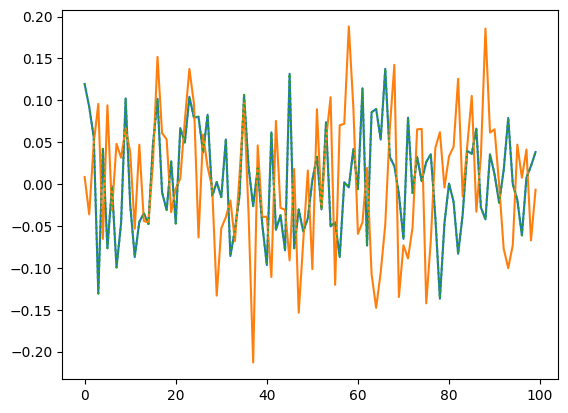

In [10]:
noise_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.NoiseGenerator",
    "spectrum_noise_min": 0.01,
    "spectrum_noise_max": 0.1,
    "seed": 42
})

sample_spectrum = torch.zeros(1,1,100)

noise_generator = instantiate(noise_generator_config)
noisy_spectrum = noise_generator(sample_spectrum)
plt.plot(noisy_spectrum[0, 0].detach().numpy())

noisy_spectrum = noise_generator(sample_spectrum)
plt.plot(noisy_spectrum[0, 0].detach().numpy())

noise_generator = instantiate(noise_generator_config)
noisy_spectrum = noise_generator(sample_spectrum)
plt.plot(noisy_spectrum[0, 0].detach().numpy(), ls=":")

# Expected: if seed is None all three lines are different. If seed is a number, lines 1 and 3 are the same


### response

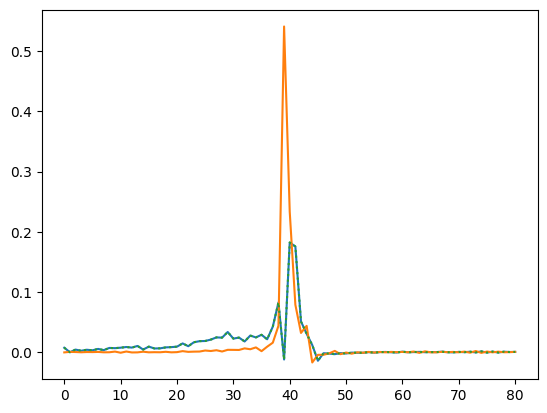

In [9]:
response_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.ResponseGenerator",
    "response_function_library": {
        "_target_": "shimnet.generators.ResponseLibrary",
        "response_files": [
            "../data/scrf_81_600MHz.pt"
        ]
    },
    "seed": 42
})

response_generator = instantiate(response_generator_config)
random_response = response_generator()
plt.plot(random_response.detach().numpy()[0,0])

random_response = response_generator()
plt.plot(random_response.detach().numpy()[0,0])

response_generator = instantiate(response_generator_config)
random_response = response_generator()
plt.plot(random_response.detach().numpy()[0,0], ls=":")

# Expected: if seed is None all three lines are different. If seed is a number, lines 1 and 3 are the same


### peaks data

In [8]:
peaks_data_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.PeaksParameterDataGenerator",
    "atom_groups_data_file": "../data/multiplets_10000_parsed.txt",
    "tff_min": -100,
    "tff_max": 100,
    "seed": 42
})

print("*** First call ****\n")
peaks_data_generator = instantiate(peaks_data_generator_config)
peaks_data = peaks_data_generator()

print("Number of multiplets generated:", len(peaks_data))
print("First multiplet data:")
for k, v in peaks_data[0].items():
    print(k, v.tolist())

print("\n*** Second call ****\n")
peaks_data = peaks_data_generator()
print("Number of multiplets generated:", len(peaks_data))
print("First multiplet data:")
for k, v in peaks_data[0].items():
    print(k, v.tolist())

print("\n*** Third call with re-initialized generator ****\n")
peaks_data_generator = instantiate(peaks_data_generator_config)
peaks_data = peaks_data_generator()
print("Number of multiplets generated:", len(peaks_data))
print("First multiplet data:")
for k, v in peaks_data[0].items():
    print(k, v.tolist())


*** First call ****

Number of multiplets generated: 7
First multiplet data:
tff_lin [58.454322814941406, 71.49539184570312, 84.53645324707031, 97.57752227783203, 67.35801696777344, 80.39908599853516, 93.44014739990234, 106.48121643066406, 76.26171112060547, 89.30278015136719, 102.34384155273438, 115.3849105834961]
thf_lin [0.004087650217115879, 0.012262950651347637, 0.012262950651347637, 0.004087650217115879, 0.008175300434231758, 0.024525901302695274, 0.024525901302695274, 0.008175300434231758, 0.004087650217115879, 0.012262950651347637, 0.012262950651347637, 0.004087650217115879]
twf_lin [1.3474119901657104, 1.3474119901657104, 1.3474119901657104, 1.3474119901657104, 1.3474119901657104, 1.3474119901657104, 1.3474119901657104, 1.3474119901657104, 1.3474119901657104, 1.3474119901657104, 1.3474119901657104, 1.3474119901657104]
trf_lin [0.42940449714660645, 0.42940449714660645, 0.42940449714660645, 0.42940449714660645, 0.42940449714660645, 0.42940449714660645, 0.42940449714660645, 0.429

### clean spectrum from multiplets

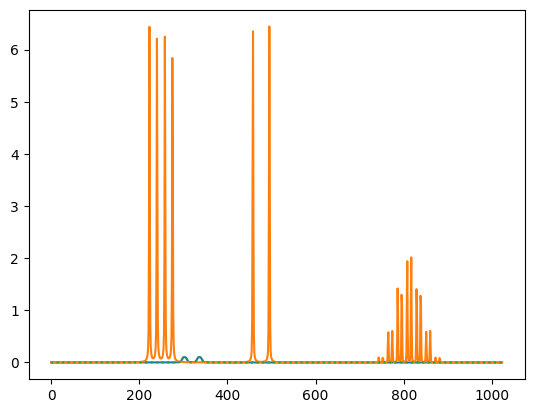

In [9]:
theoretical_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.TheoreticalMultipletSpectraGenerator",
    "peaks_parameter_generator": {
        "_target_": "shimnet.generators.PeaksParameterDataGenerator",
        "atom_groups_data_file": "../data/multiplets_10000_parsed.txt",
        # "tff_min": -100,
        # "tff_max": 100,
        "seed": 41
    },
    "pixels": 1024,
    "frq_step": 11160.7142857 / 32768,
    "include_tff_relative": True,
    "relative_frequency_min": -0.4,
    "relative_frequency_max": 0.4
})

theoretical_generator = instantiate(theoretical_generator_config)
theoretical_spectrum, theoretical_spectrum_params = theoretical_generator()
plt.plot(theoretical_spectrum[0].detach().numpy())

theoretical_spectrum, theoretical_spectrum_params = theoretical_generator()
plt.plot(theoretical_spectrum[0].detach().numpy())

theoretical_generator = instantiate(theoretical_generator_config)
theoretical_spectrum, theoretical_spectrum_params = theoretical_generator()
plt.plot(theoretical_spectrum[0].detach().numpy(), ls=":")
# Expected: if seed is None all three lines are different. If seed is a number, lines 1 and 3 are the same


### Full data generator

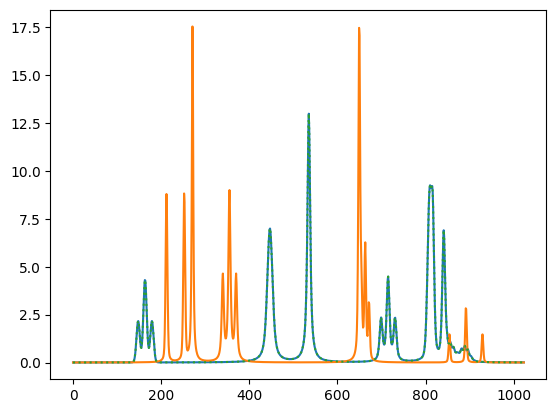

In [10]:
theoretical_generator_config.peaks_parameter_generator.seed = None  # Propagate seed from data generator

data_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.Generator",
    "clean_spectra_generator": theoretical_generator_config,
    "response_generator": response_generator_config,
    "noise_generator": noise_generator_config,
    "include_spectrum_data": False,
    "include_peak_mask": False,
    "include_response_function": False,
    "seed": 5,
    "batch_size": 3
})

data_generator = instantiate(data_generator_config)

data_iterator = iter(data_generator)

batch = next(data_iterator)
plt.plot(batch["theoretical_spectrum"][0,0])

batch = next(data_iterator)
plt.plot(batch["theoretical_spectrum"][0,0])

data_generator = instantiate(data_generator_config)
batch = next(iter(data_generator))
plt.plot(batch["theoretical_spectrum"][0,0], ls=":")

# Expected: if seed is None all three lines are different. If seed is a number, lines 1 and 3 are the same


## Speed benchmark

In [ ]:
from datetime import datetime
# the last commit where `get_datapipe` with torchdata is supported: d87daf331e0e0a4c04130bb769629fb86e55959e
# from shimnet.generators import get_datapipe 

In [ ]:
config_modular = OmegaConf.load("../configs/shimnet_600_modular.yaml").data
# config_standard = OmegaConf.load("../configs/shimnet_600.yaml").data

# config_standard.response_functions_files = ["../" + p for p in config_standard.response_functions_files]
# config_standard.atom_groups_data_file = "../" + config_standard.atom_groups_data_file

config_modular.clean_spectra_generator.peaks_parameter_generator.atom_groups_data_file = "../" + config_modular.clean_spectra_generator.peaks_parameter_generator.atom_groups_data_file
config_modular.response_generator.response_function_library.response_files = ["../" + p for p in config_modular.response_generator.response_function_library.response_files]

In [ ]:
batch_size = 512
config_modular.batch_size = batch_size

data_generators = {
    # "standard": get_datapipe(**config_standard, batch_size=batch_size, include_response_function=True),
    "modular": instantiate(config_modular)
}


/home/mbuk/miniconda3/envs/shimnetgpu2/lib/python3.11/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()


In [14]:
n_batches = 50

timings = {}
for k, generator in data_generators.items():
    # print(f"Timing data generator: {k}")
    data_iterator = iter(generator)
    start_time = datetime.now()
    for i in range(n_batches):
        batch = next(data_iterator)
    total_seconds = (datetime.now() - start_time).total_seconds()
    timings[k] = total_seconds
    print(f"  Time for {n_batches} batches of size {batch_size}: {total_seconds:.2f} seconds")

  Time for 50 batches of size 512: 56.98 seconds
  Time for 50 batches of size 512: 31.71 seconds


### Generator from peak list

In [3]:
peaks_data

[{'tff_lin': -23.42724609375,
  'thf_lin': tensor([ 2.9500,  6.4500,  1.9200,  0.6000,  8.3400, 14.1700, 10.6300,  0.8300,
           4.3200, 16.1700,  9.8900,  2.3700,  0.6300,  8.2600, 25.9800,  8.8200,
           4.7300, 10.6500,  5.7300,  9.3700,  1.4600,  1.4000,  2.9500,  1.1900]),
  'twf_lin': tensor([0.8500, 1.3300, 1.0000, 1.0800, 1.0200, 1.1800, 1.2700, 1.0300, 1.0700,
          1.2300, 1.2700, 0.7400, 2.0200, 1.6300, 1.9200, 1.3700, 2.8600, 2.3200,
          1.5700, 1.5400, 0.9800, 1.0300, 1.3900, 1.1200]),
  'trf_lin': tensor([0.8333, 1.0000, 0.5917, 1.0000, 0.6173, 1.0000, 0.9615, 0.4762, 0.8264,
          1.0000, 0.6757, 0.6452, 0.7143, 0.5376, 0.5495, 0.5263, 0.4926, 1.0000,
          0.7143, 0.5587, 0.7143, 0.5376, 0.9804, 0.7194])},
 {'tff_lin': 20.17906951904297,
  'thf_lin': tensor([43.1000]),
  'twf_lin': tensor([2.2300]),
  'trf_lin': tensor([0.6757])},
 {'tff_lin': 88.154296875,
  'thf_lin': tensor([1.7987e+02, 9.0000e-02]),
  'twf_lin': tensor([1.1100, 1.1000]),


In [4]:
peaks_data_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.MultipletDataFromMultipletsLibrary",
    "multiplets_library": {
        "_target_": "shimnet.generators.MultipletsLibrary",
        "csv_files_paths": ["../data/multiplets_lists/azydekbenzylu_sub1_mono-click.csv"],
        "peak_data_parser": {
            "_target_": "shimnet.generators.PeaksParametersParser",
        },
    },
    "use_original_peak_position": False,
    "number_of_signals_min": None,
    "number_of_signals_max": None,
    "tff_min": -100,
    "tff_max": 100,
    "seed": None
})

print("*** First call ****\n")
peaks_data_generator = instantiate(peaks_data_generator_config)
peaks_data = peaks_data_generator()

print("Number of multiplets generated:", len(peaks_data))
print("First multiplet data:")
for k, v in peaks_data[0].items():
    print(k, v.tolist())

print("\n*** Second call ****\n")
peaks_data = peaks_data_generator()
print("Number of multiplets generated:", len(peaks_data))
print("First multiplet data:")
for k, v in peaks_data[0].items():
    print(k, v.tolist())

print("\n*** Third call with re-initialized generator ****\n")
peaks_data_generator = instantiate(peaks_data_generator_config)
peaks_data = peaks_data_generator()
print("Number of multiplets generated:", len(peaks_data))
print("First multiplet data:")
for k, v in peaks_data[0].items():
    print(k, v.tolist())


*** First call ****

Number of multiplets generated: 9
First multiplet data:
tff_lin [43.89697265625, 42.63671875, 41.01708984375, 38.19677734375, 36.51708984375, 35.376953125, 34.23681640625, 31.716796875, 30.39697265625, 28.296875, 27.51708984375, 26.43701171875, 23.97705078125, 16.95703125, 15.216796875, 12.3369140625, 10.05712890625, 8.2568359375, 6.63671875, 4.05712890625, 1.4169921875, -1.34326171875, -2.9033203125, -4.52294921875]
thf_lin [2.950000047683716, 6.449999809265137, 1.9199999570846558, 0.6000000238418579, 8.34000015258789, 14.170000076293945, 10.630000114440918, 0.8299999833106995, 4.320000171661377, 16.170000076293945, 9.890000343322754, 2.369999885559082, 0.6299999952316284, 8.260000228881836, 25.979999542236328, 8.819999694824219, 4.730000019073486, 10.649999618530273, 5.730000019073486, 9.369999885559082, 1.4600000381469727, 1.399999976158142, 2.950000047683716, 1.190000057220459]
twf_lin [0.8500000238418579, 1.3300000429153442, 1.0, 1.0800000429153442, 1.01999998

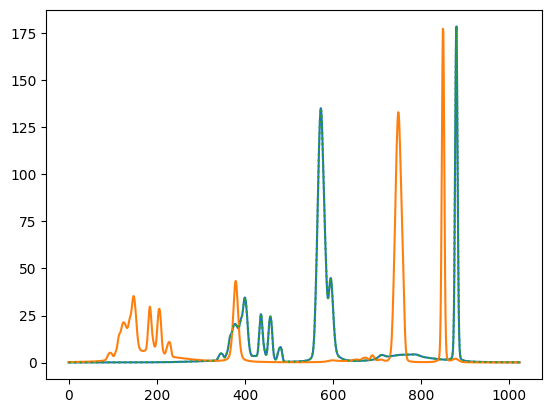

In [7]:
theoretical_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.TheoreticalMultipletSpectraGenerator",
    "peaks_parameter_generator": {
        "_target_": "shimnet.generators.MultipletDataFromMultipletsLibrary",
        "multiplets_library": {
            "_target_": "shimnet.generators.MultipletsLibrary",
            "csv_files_paths": ["../data/multiplets_lists/azydekbenzylu_sub1_mono-click.csv"],
            "peak_data_parser": {
                "_target_": "shimnet.generators.PeaksParametersParser",
            },
        },
        "use_original_peak_position": False,
        "number_of_signals_min": None,
        "number_of_signals_max": None,
        # "tff_min": -100,
        # "tff_max": 100,
        "seed": 42
    },
    "pixels": 1024,
    "frq_step": 11160.7142857 / 32768,
    "include_tff_relative": True,
    "relative_frequency_min": -0.4,
    "relative_frequency_max": 0.4
})

theoretical_generator = instantiate(theoretical_generator_config)
theoretical_spectrum, theoretical_spectrum_params = theoretical_generator()
plt.plot(theoretical_spectrum[0].detach().numpy())

theoretical_spectrum, theoretical_spectrum_params = theoretical_generator()
plt.plot(theoretical_spectrum[0].detach().numpy())

theoretical_generator = instantiate(theoretical_generator_config)
theoretical_spectrum, theoretical_spectrum_params = theoretical_generator()
plt.plot(theoretical_spectrum[0].detach().numpy(), ls=":")


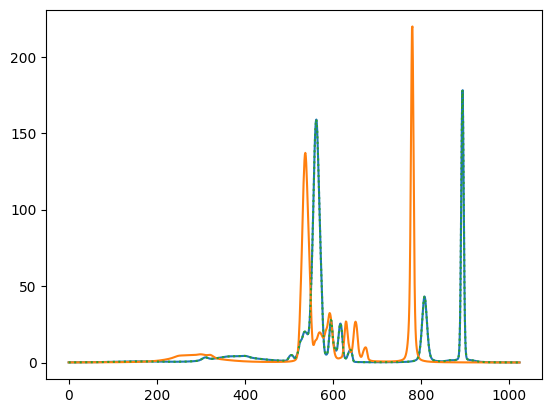

In [11]:
theoretical_generator_config.peaks_parameter_generator.seed = None  # Propagate seed from data generator

data_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.Generator",
    "clean_spectra_generator": theoretical_generator_config,
    "response_generator": response_generator_config,
    "noise_generator": noise_generator_config,
    "include_spectrum_data": False,
    "include_peak_mask": False,
    "include_response_function": False,
    "seed": 5,
    "batch_size": 3
})

data_generator = instantiate(data_generator_config)

data_iterator = iter(data_generator)

batch = next(data_iterator)
plt.plot(batch["theoretical_spectrum"][0,0])

batch = next(data_iterator)
plt.plot(batch["theoretical_spectrum"][0,0])

data_generator = instantiate(data_generator_config)
batch = next(iter(data_generator))
plt.plot(batch["theoretical_spectrum"][0,0], ls=":")

# Expected: if seed is None all three lines are different. If seed is a number, lines 1 and 3 are the same


In [ ]:
OmegaConf.save(data_generator_config, "../configs/data_generator_from_peak_list.yaml")